# Documentation — Utilisation de l'API Fouille d'image BnF

**Projet** : Gallica Images — Analyse d'illustrations de l'œuvre d'Ovide  
**Date** : Avril 2026

---

Ce notebook documente les appels API réalisés dans le cadre de l'évaluation de la version preprod `2.3.1`.  
Il couvre les fonctionnalités de filtrage ainsi que la recherche sémantique CLIP, dont le bon format  
de requête a été découvert en inspectant les appels réseau de l'interface web de l'API.

---

## Configuration

In [2]:
import requests
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
from PIL import Image
from io import BytesIO
from IPython.display import display
warnings.filterwarnings('ignore')

BASE_URL = "https://gallica-search-api-preprod.bnf.lajavaness.com"
print(f"API : {BASE_URL}")

API : https://gallica-search-api-preprod.bnf.lajavaness.com


---
## Endpoint 1 — `GET /status`

Appel HTTP `GET` simple, sans paramètres.  
Retourne un objet JSON avec un seul champ : la version de l'API.

```json
{ "version": "2.3.1" }
```

In [2]:
t0 = time.time()
r = requests.get(f"{BASE_URL}/status", timeout=10)
latence = round((time.time() - t0) * 1000)

print("Réponse :", r.json())
print("Latence :", latence, "ms")

Réponse : {'version': '2.4.2'}
Latence : 156 ms


---
## Endpoint 2 — `GET /healthcheck`

Appel HTTP `GET` simple, sans paramètres.  
Retourne l'état des trois composants internes de l'API :

- `is_healthy` — état général de l'API
- `solr_healthy` — état du moteur de recherche Solr
- `embedding_healthy` — état du service de calcul de vecteurs CLIP

```json
{ "is_healthy": true, "solr_healthy": true, "embedding_healthy": true }
```

**Remarque** : `embedding_healthy: true` indique que le service CLIP est actif côté serveur,  
mais cela ne suffit pas à activer la recherche sémantique — le format de la requête doit également  
utiliser la syntaxe correcte (voir Endpoint 4).

In [3]:
r = requests.get(f"{BASE_URL}/healthcheck", timeout=10)
h = r.json()

print("is_healthy        :", h.get("is_healthy"))
print("solr_healthy      :", h.get("solr_healthy"))
print("embedding_healthy :", h.get("embedding_healthy"))

is_healthy        : True
solr_healthy      : True
embedding_healthy : True


---
## Endpoint 3 — `POST /api/search` — Filtrage par métadonnées

Appel HTTP `POST` avec un body JSON.

Les filtres sont traités directement par Solr — aucun calcul CLIP n'est impliqué.  
Ils s'appliquent sur les métadonnées de chaque illustration indexée.

Avec `rows: 0`, l'API ne retourne aucun document mais fournit les statistiques globales  
(`response.numFound`) et les facettes (`facet_counts`).

**Filtres disponibles utilisés ici :**
- `filter_properties_genre` — genre iconographique
- `filter_properties_technical_process` — technique de production
- `filter_physical_chromatic_mode` — mode chromatique (`nb`, `monochrome`, `couleur`)
- `filter_context_corpus` — corpus d'appartenance
- `search_after_context_date` / `search_before_context_date` — bornes de date (format `YYYY`)

Champs utilisés dans la réponse :
- `response.numFound` — nombre de documents correspondant
- `responseHeader.QTime` — temps de traitement côté serveur en ms
- `response.docs` — liste des illustrations retournées
- `docs[i].link` — URL IIIF de l'illustration
- `docs[i].context_title`, `docs[i].context_date`, `docs[i].properties_genre`

In [4]:
# Volume total de la base
r = requests.post(f"{BASE_URL}/api/search",
    json={"rows": 0},
    headers={"Content-Type": "application/json"})
data = r.json()

print("numFound :", f"{data['response']['numFound']:,}")
print("QTime    :", data["responseHeader"]["QTime"], "ms")
print()

facets = data["facet_counts"]["facet_fields"]["context_type"]
types  = {facets[i]: facets[i+1] for i in range(0, len(facets), 2) if facets[i+1] > 0}
print("Répartition par type :")
for k, v in sorted(types.items(), key=lambda x: -x[1]):
    print(f"  {k:<20} : {v:>12,}")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [5]:
# Tableau comparatif de plusieurs filtres
tests_filtres = [
    {
        "label": "Scènes + Figures mythologiques",
        "payload": {
            "rows": 0,
            "filter_properties_genre": ["Scènes mythologiques", "Figures mythologiques"]
        }
    },
    {
        "label": "Gravures sur bois N&B 1500-1700",
        "payload": {
            "rows": 0,
            "filter_properties_technical_process": ["gravure sur bois"],
            "filter_physical_chromatic_mode": ["nb"],
            "search_after_context_date": "1500",
            "search_before_context_date": "1700"
        }
    },
    {
        "label": "Corpus Bnu Strasbourg",
        "payload": {
            "rows": 0,
            "filter_context_corpus": [
                "Collections de la Bibliothèque nationale et universitaire de Strasbourg"
            ]
        }
    }
]

resultats = []
for t in tests_filtres:
    r  = requests.post(f"{BASE_URL}/api/search",
        json=t["payload"], headers={"Content-Type": "application/json"})
    n  = r.json()["response"]["numFound"]
    qt = r.json()["responseHeader"]["QTime"]
    resultats.append({"Filtre": t["label"], "Résultats": f"{n:,}", "QTime (ms)": qt})

display(pd.DataFrame(resultats))

,Filtre,Résultats,QTime (ms)
0,Scènes + Figures mythologiques,955,24
1,Gravures sur bois N&B 1500-1700,"1,066",24
2,Corpus Bnu Strasbourg,"35,034",44


---
## Endpoint 4 — `POST /api/search` — Recherche sémantique CLIP

Appel HTTP `POST` avec un body JSON.

Ce mode active le moteur CLIP pour une recherche par similarité visuelle et sémantique.  
Le format correct du `search_text_query` a été découvert en inspectant les requêtes réseau  
de l'interface web (onglet Network des outils développeur du navigateur).

**Format requis pour activer CLIP :**
```
global_search all "<terme>"
```

Sans ce préfixe, Solr reçoit `q=*:*` et ignore le texte — aucune recherche sémantique n'a lieu.

Body envoyé :
```json
{
  "search_text_query": "global_search all \"metamorphose\"",
  "type": "embedding",
  "image_vector": [],
  "rows": 5
}
```

Champs utilisés dans la réponse :
- `responseHeader.params.q` — contient `{!knn f=content_embedding topK=N}[vecteur...]`, preuve que CLIP est actif
- `response.maxScore` — score de similarité maximum, inférieur à 1.0
- `docs[i].score` — score de similarité cosinus entre la requête et l'illustration

Les filtres de métadonnées sont combinables avec la recherche CLIP dans le même body.

In [6]:
payload = {
    "search_text_query": 'global_search all "metamorphose"',
    "type": "embedding",
    "image_vector": [],
    "rows": 5,
    "start": 0
}

r    = requests.post(f"{BASE_URL}/api/search",
    json=payload, headers={"Content-Type": "application/json"})
data = r.json()

q          = data["responseHeader"]["params"].get("q", "")
clip_actif = q.startswith("{!knn")

print("CLIP actif :", "✓" if clip_actif else "✗")
print("q (extrait) :", q[:80], "...")
print("maxScore   :", data["response"]["maxScore"])
print("scores     :", [round(doc["score"], 4) for doc in data["response"]["docs"]])
print()
print("Résultats :")
for doc in data["response"]["docs"]:
    print(f"  score={round(doc['score'],4)} | {(doc.get('context_title') or [''])[0][:50]} | {str(doc.get('context_date',''))[:4]}")

CLIP actif : ✓
q (extrait) : {!knn f=content_embedding topK=5}[-0.011815563775599003, -0.028165990486741066,  ...
maxScore   : 0.5614337
scores     : [0.5614, 0.5614, 0.5586, 0.5581, 0.5575]

Résultats :
  score=0.5614 | [Recueil. Notre Faust, chorégraphie de Maurice Béj | 1985
  score=0.5614 | [Kagemi, spectacle de la compagnie Sankai Juku. Ph | 2000
  score=0.5586 | [Médée, texte d'Euripide : photographies / Daniel  | 1989
  score=0.5581 | [Le songe d'une nuit d'été : photographies / Danie | 1990
  score=0.5575 | [Unetsu, spectacle de la compagnie Sankai Juku. Ph | 1988


---
## Endpoint 5 — `GET /api/ouvrages/{ark}/illustrations`

Appel HTTP `GET` avec l'ARK du livre dans l'URL, sans paramètres supplémentaires.  
Retourne toutes les illustrations d'un livre numérisé avec leurs métadonnées complètes.

 — il est le seul à exposer les vecteurs CLIP (`content_embedding`) calculés par le modèle pour chaque illustration indexée.

```
GET /api/ouvrages/{ark}/illustrations
```

Champs utilisés dans la réponse :
- `ark` — identifiant unique de l'illustration
- `view_number` — numéro de page dans le livre
- `metas.link` — URL IIIF pour télécharger l'image
- `metas.content_embedding` — vecteur CLIP 768D
  
**Remarque** : tous les livres n'ont pas leurs embeddings calculés.  
Il faut vérifier que `content_embedding` existe et contient bien 768 valeurs.

In [7]:
ARK_SALOMON = "btv1b2200047r"
    
r = requests.get(
    f"{BASE_URL}/api/ouvrages/{ARK_SALOMON}/illustrations",
    timeout=30
)
illustrations = r.json()

# Vérification des embeddings
avec_embedding = [
    i for i in illustrations
    if i.get("metas", {}).get("content_embedding")
    and len(i["metas"]["content_embedding"]) == 768
]

print(f"Illustrations totales      : {len(illustrations)}")
print(f"Avec embedding CLIP (768D) : {len(avec_embedding)}")
print(f"Sans embedding             : {len(illustrations) - len(avec_embedding)}")
print()

# Exemple d'une illustration
illus = avec_embedding[0]
metas = illus.get("metas", {})

print("Exemple d'illustration :")
print(f"  ark          : {illus.get('ark')}")
print(f"  view_number  : {illus.get('view_number')}")
print(f"  link         : {metas.get('link', '')[:60]}...")
print(f"  embedding    : [{metas['content_embedding'][0]}, "
      f"{metas['content_embedding'][1]}, ...] ({len(metas['content_embedding'])}D)")
print()

# Champs disponibles dans metas
print("Champs disponibles dans metas :")
for cle in metas.keys():
    if cle != "content_embedding":
        print(f"  {cle} : {str(metas.get(cle, ''))[:60]}")

Illustrations totales      : 184
Avec embedding CLIP (768D) : 184
Sans embedding             : 0

Exemple d'illustration :
  ark          : bfkfk930z5q
  view_number  : 1
  link         : https://openapi.bnf.fr/iiif/image/v3/ark:/12148/btv1b2200047...
  embedding    : [-0.032671160995960236, -0.007089294493198395, ...] (768D)

Champs disponibles dans metas :
  link : https://openapi.bnf.fr/iiif/image/v3/ark:/12148/btv1b2200047
  ark : bfkfk930z5q
  parent_ark : btv1b2200047r
  view_number : 1
  image_coordinates : [0.029947853088378905, 0.10969676971435546, 0.86350139617919
  confidence_level : 0.936000645160675
  segmentation_model : 20250214_134345-segmentation-final-yolov8l_pt
  context_ark : btv1b2200047r
  physical_height : 1245
  physical_width : 884
  physical_ratio : 1.408371040723982
  physical_orientation : 0
  physical_size : 1100580
  content_title : 
  content_text : MPR
  content_description : ['Figures mythologiques']
  context_title : ["[Illustrations de La Métamorphose

## Endpoint 6 — `POST /api/image` — Calcul d'embedding CLIP

Calcule le vecteur CLIP 768D d'une image envoyée en multipart/form-data.
Cet endpoint est utilisé par l'interface web de Gallica Images pour calculer
l'embedding d'une image uploadée par l'utilisateur avant de lancer la recherche.

**Utilité :** permet de rechercher des illustrations similaires dans Gallica
à partir de n'importe quelle image externe — non indexée dans l'API.

**Format de la requête :**
- Méthode : `POST`
- Content-Type : `multipart/form-data`
- Champ requis : `image` — fichier image (JPEG, PNG)

**Réponse :** liste de 768 floats — vecteur CLIP normalisé, directement
utilisable dans `POST /api/search` avec `type="image"`.

**Note :** la similarité entre ce vecteur et les embeddings précalculés
de Gallica est de ~0.995 — légère différence due au preprocessing JPEG.

**Remarque :** si l'image envoyée est une page de texte sans illustration,
l'API retourne des résultats similaires par texture typographique — pas par
contenu iconographique. Pour de meilleurs résultats, envoyer des illustrations
préalablement segmentées par YOLO.

In [1]:
import requests, json

BASE_URL = "https://gallica-search-api-preprod.bnf.lajavaness.com"

# ── Endpoint 6 — POST /api/image ─────────────────────────────
# Envoyer une image et récupérer son vecteur CLIP 768D

url_test  = "https://api.digitale-sammlungen.de/iiif/image/v2/bsb10139926_00025/full/full/0/default.jpg"
img_bytes = requests.get(url_test, timeout=15).content

r = requests.post(
    f"{BASE_URL}/api/image",
    files={"image": ("image.jpg", img_bytes, "image/jpeg")},
    timeout=30
)

print(f"HTTP {r.status_code}")
vecteur = json.loads(r.text)
print(f"Dimension du vecteur : {len(vecteur)}")
print(f"Premiers éléments    : {vecteur[:5]}")

# Le vecteur est directement utilisable dans /api/search
docs = requests.post(f"{BASE_URL}/api/search",
    json={"type": "image", "image_vector": vecteur, "rows": 3, "start": 0},
    headers={"Content-Type": "application/json"}, timeout=30
).json()["response"]["docs"]

print(f"\nTop 3 résultats similaires :")
for doc in docs:
    titre = (doc.get("context_title") or [""])[0][:60]
    score = round(doc.get("score", 0), 4)
    print(f"  score={score} | {titre}")

HTTP 200
Dimension du vecteur : 768
Premiers éléments    : [-0.059080902487039566, -0.04175456240773201, -0.0047039370983839035, -0.028465859591960907, 0.0007216049707494676]

Top 3 résultats similaires :
  score=0.9409 | Ein new Künstlich Modelbuch mitt Grosser Mühe und Sonderm vl
  score=0.9394 | Thewerdanck des Edlen streitbaren Helden und Ritters ehrund 
  score=0.9393 | Thewerdanck des Edlen streitbaren Helden und Ritters ehrund 


---
## Visualisation des résultats

Pour chaque document retourné par `/api/search`, le champ `link` contient une URL IIIF.  
On fait un second appel HTTP `GET` vers cette URL pour télécharger l'image.

On utilise `PIL.Image.open` pour décoder l'image car il détecte automatiquement le format  
(JPEG, PNG...) contrairement à `matplotlib.image.imread` qui suppose du PNG en mémoire.

Flux complet :
```
POST /api/search  →  docs[i].link  →  GET url IIIF  →  PIL.Image.open  →  ax.imshow
```

In [8]:
def afficher_images(docs, titre="", max_imgs=5):
    docs = [d for d in docs if d.get("link")][:max_imgs]
    if not docs:
        print("Aucune image disponible.")
        return

    fig, axes = plt.subplots(1, len(docs), figsize=(4 * len(docs), 5))
    if len(docs) == 1:
        axes = [axes]

    for ax, doc in zip(axes, docs):
        try:
            resp = requests.get(doc["link"], timeout=10)
            img  = Image.open(BytesIO(resp.content))
            ax.imshow(img, cmap="gray")
        except:
            ax.text(0.5, 0.5, "Image\nnon dispo", ha="center", va="center",
                    transform=ax.transAxes, color="gray")

        score     = round(doc.get("score", 0), 4)
        titre_doc = (doc.get("context_title") or [""])[0][:35]
        date      = str(doc.get("context_date", ""))[:4]
        genre     = (doc.get("properties_genre") or [""])[0][:25]
        ax.set_title(f"score: {score}\n{titre_doc}\n{date}  {genre}", fontsize=7)
        ax.axis("off")

    fig.suptitle(titre, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

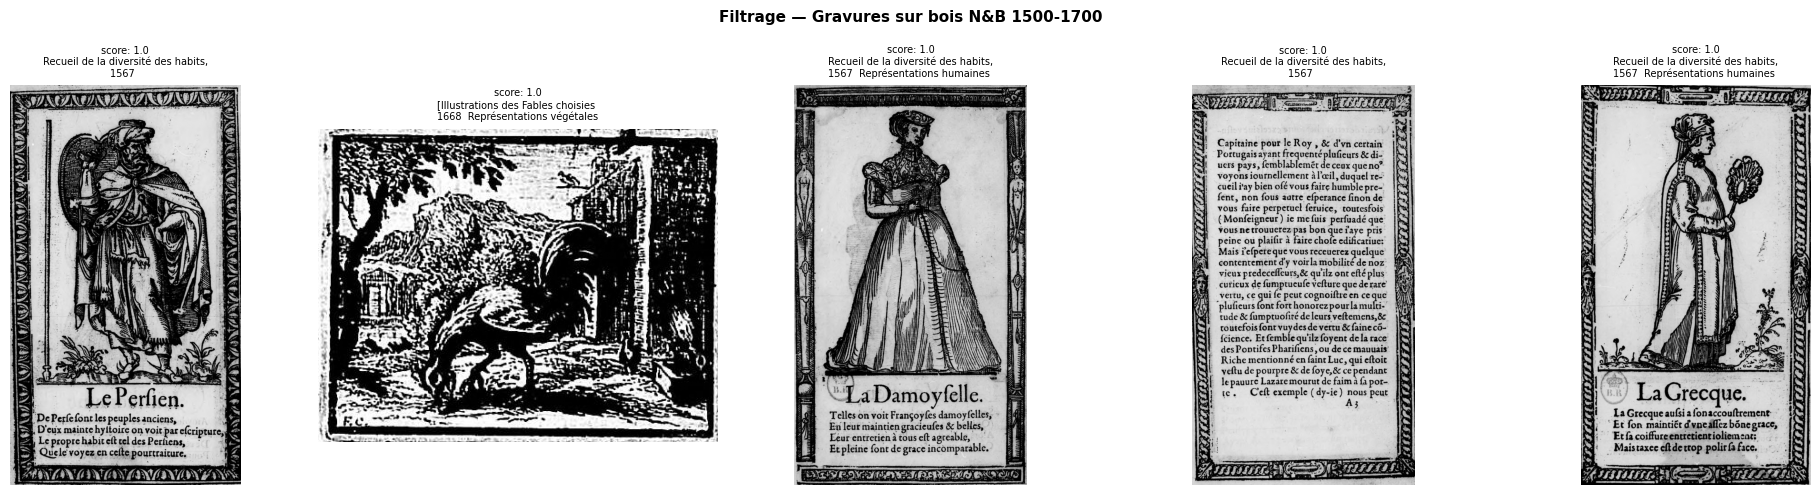

In [9]:
# Filtrage — Gravures sur bois N&B 1500-1700
r = requests.post(f"{BASE_URL}/api/search",
    json={
        "rows": 5,
        "filter_properties_technical_process": ["gravure sur bois"],
        "filter_physical_chromatic_mode": ["nb"],
        "search_after_context_date": "1500",
        "search_before_context_date": "1700"
    },
    headers={"Content-Type": "application/json"})
afficher_images(r.json()["response"]["docs"],
    titre="Filtrage — Gravures sur bois N&B 1500-1700")

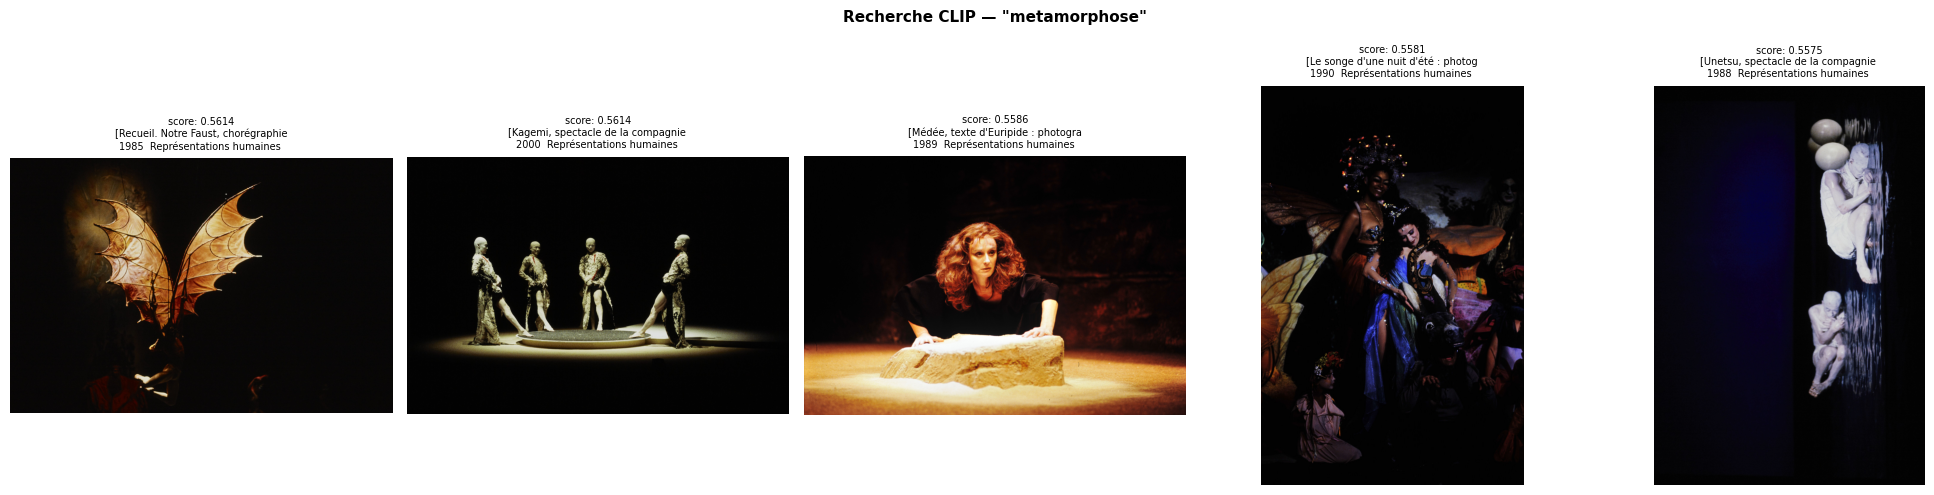

In [10]:
# Recherche CLIP — metamorphose
r = requests.post(f"{BASE_URL}/api/search",
    json={
        "search_text_query": 'global_search all "metamorphose"',
        "type": "embedding",
        "image_vector": [],
        "rows": 5,
        "start": 0
    },
    headers={"Content-Type": "application/json"})
afficher_images(r.json()["response"]["docs"],
    titre='Recherche CLIP — "metamorphose"')

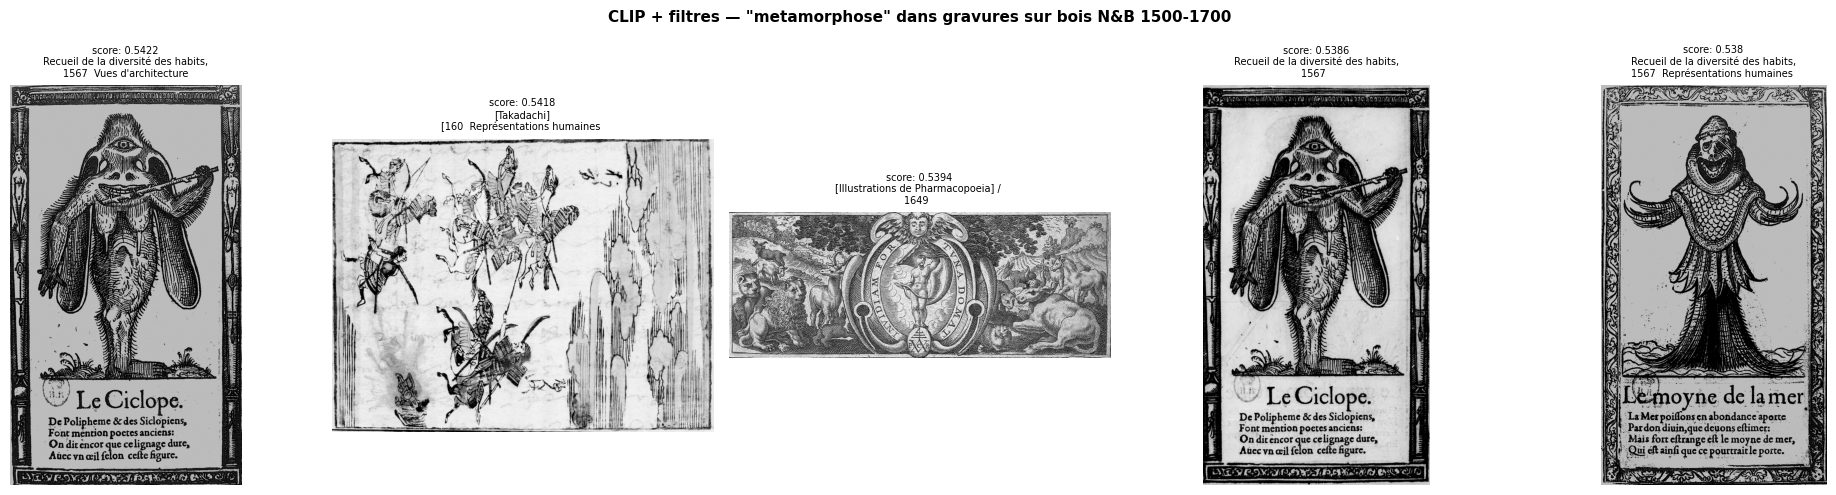

In [11]:
# CLIP + filtres combinés
r = requests.post(f"{BASE_URL}/api/search",
    json={
        "search_text_query": 'global_search all "metamorphose"',
        "type": "embedding",
        "image_vector": [],
        "rows": 5,
        "filter_properties_technical_process": ["gravure sur bois"],
        "filter_physical_chromatic_mode": ["nb"],
        "search_after_context_date": "1500",
        "search_before_context_date": "1700"
    },
    headers={"Content-Type": "application/json"})
afficher_images(r.json()["response"]["docs"],
    titre='CLIP + filtres — "metamorphose" dans gravures sur bois N&B 1500-1700')

## Apres retour Margaux:

In [6]:
import requests
BASE_URL = "https://galimages-search.bnf.fr"

r = requests.post(f"{BASE_URL}/api/search",
    json={"rows": 0}, headers={"Content-Type": "application/json"})

print("HTTP", r.status_code)
if r.status_code == 200:
    data = r.json()
    print("numFound :", f"{data['response']['numFound']:,}")
    ff = data.get("facet_counts", {}).get("facet_fields", {})
    for champ in ["properties_technical_process", "properties_material"]:
        vals = ff.get(champ) or []
        d = {vals[i]: vals[i+1] for i in range(0, len(vals), 2)}
        print(f"\n{champ} ({len(d)} valeurs) :")
        for v, n in sorted(d.items(), key=lambda x: -x[1])[:15]:
            print(f"   {v:<45} : {n:>10,}")
else:
    print(r.text[:300])

HTTP 200
numFound : 6,714,912

properties_technical_process (95 valeurs) :
   diapositive                                   :    132,192
   eau-forte                                     :     64,346
   gravure sur bois                              :     47,824
   burin                                         :     34,396
   aquarelle                                     :     34,218
   lithographie                                  :     33,208
   pochoir. Voir : gravure au pochoir            :     23,385
   plume                                         :     21,935
   gouache                                       :     18,273
   collodion. Voir : procédé au collodion        :     17,392
   mine de plomb. Voir : crayon graphite         :     15,725
   bromure d'argent. Voir : procédé au bromure d'argent :      7,564
   gélatino-bromure d'argent. Voir : procédé au bromure d'argent :      7,547
   chromolithographie. Voir : lithographie       :      6,037
   lavis d'encre                  

In [12]:
import requests
BASE_URL = "https://galimages-search.bnf.fr"

r = requests.post(f"{BASE_URL}/api/search",
    json={"type": "textuelle", "rows": 1,
          "filter_properties_technical_process": ["gravure sur bois"]},
    headers={"Content-Type": "application/json"}, timeout=30)

doc = r.json()["response"]["docs"][0]
link = doc["link"]
print("URL COMPLÈTE :")
print(link)
print()
print("Longueur :", len(link))

# Tester le téléchargement
img_r = requests.get(link, timeout=20)
print("\nTéléchargement direct → HTTP", img_r.status_code)
print("Content-Type :", img_r.headers.get("Content-Type"))

URL COMPLÈTE :
https://openapi.bnf.fr/iiif/image/v3/ark:/12148/btv1b10848583d/f21/pct:6.2430,26.1914,14.0050,7.0868/max/0/default.jpg

Longueur : 118

Téléchargement direct → HTTP 200
Content-Type : image/jpeg


---
*Documentation réalisée dans le cadre du projet Gallica Images — Bnu Strasbourg, avril 2026*